In [1]:
# Cell 1: Define paths for cross-validation folds

NAME = 'vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle'

TCES_FILE = "../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-all.csv"




fold_paths = []
for i in range(5):
    fold_info = {
        'train_files': f'../mnt/tess/astronet/fold_{i}_train/*',
        'val_files': f'../mnt/tess/astronet/fold_{i}_val/*',
        'model_dir': f'../mnt/tess/astronet/checkpoints/{NAME}_base_new_2500_crossval_fold{i}'
    }
    fold_paths.append(fold_info)

print(fold_paths)

# Print current working directory

import os
os.getcwd()

# if current working directory finishes in 'pablomer', change to 'pablomer/Astronet-Triage'
if os.getcwd().split('/')[-1] == 'pablomer':
    os.chdir('/pdo/users/pablomer/Astronet-Triage')
    os.getcwd()

[{'train_files': '../mnt/tess/astronet/fold_0_train/*', 'val_files': '../mnt/tess/astronet/fold_0_val/*', 'model_dir': '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold0'}, {'train_files': '../mnt/tess/astronet/fold_1_train/*', 'val_files': '../mnt/tess/astronet/fold_1_val/*', 'model_dir': '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold1'}, {'train_files': '../mnt/tess/astronet/fold_2_train/*', 'val_files': '../mnt/tess/astronet/fold_2_val/*', 'model_dir': '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold2'}, {'train_files': '../mnt/tess/astronet/fold_3_train/*', 'val_files': '../mnt/tess/astronet/fold_3_val/*', 'model_dir': '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold3'}, {'train_fil

In [2]:
# Cell 2: Load models for each fold

import tensorflow as tf
from astronet import predict


# Load models for each fold, dynamically identifying the correct saved model directory
def run_predictions(fold_info):
    model_subdirs = [d for d in os.listdir(fold_info['model_dir']) if os.path.isdir(os.path.join(fold_info['model_dir'], d))]
    if not model_subdirs:
        raise FileNotFoundError(f"No saved models found in {fold_info['model_dir']}")
    latest_model_subdir = sorted(model_subdirs)[-1]
    saved_model_path = os.path.join(fold_info['model_dir'], latest_model_subdir)
    return predict.predict(model_dir=saved_model_path, data_files=fold_info['val_files'], output_file=None)

all_predictions = []
for fold_info in fold_paths:
    print(f"\n Evaluating fold with model from {fold_info['model_dir']}")
    preds = run_predictions(fold_info)
    all_predictions.append(preds)

print("Predictions for all folds completed.")

2025-03-14 09:34:41.002115: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 09:34:42.482186: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



 Evaluating fold with model from ../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold0


2025-03-14 09:34:49.949299: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46672 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6
2025-03-14 09:34:49.950444: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46672 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
2025-03-14 09:34:49.951258: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46672 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6
2025-03-14 09:34:49.952038: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 46672 MB memory:  -> device: 3, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, 

0 records

2025-03-14 09:34:53.262815: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-03-14 09:34:54.599668: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-03-14 09:34:54.614258: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


...

1878 records
 Evaluating fold with model from ../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold3
0 records

2025-03-14 09:36:14.392653: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


1878 records
 Evaluating fold with model from ../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500_crossval_fold4
0 records

2025-03-14 09:36:39.884355: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


1878 recordsPredictions for all folds completed.


In [ ]:
import pickle
import pandas as pd

# Example list of tuples where the first element is a DataFrame

# Save the list of tuples to a file
with open('data.pkl', 'wb') as f:
    pickle.dump(all_predictions, f)

# # Later, load the list from the file
# with open('data.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)

# # Verify the data
# print(loaded_data)


In [7]:
type(all_predictions[0])

tuple

In [57]:
all_predictions[3][0]

,astro_id,disp_p,disp_e,disp_n,disp_j
0,6178,0.967663,0.031995,0.000300,0.000042
1,6179,0.999005,0.000862,0.000102,0.000031
2,6180,0.972864,0.010059,0.004331,0.012747
3,6181,0.881406,0.115047,0.002461,0.001086
4,6182,0.977087,0.020050,0.001817,0.001046
...,...,...,...,...,...
1873,8641,0.899405,0.097155,0.002266,0.001174
1874,8642,0.992169,0.007553,0.000230,0.000048
1875,8643,0.999632,0.000336,0.000027,0.000005
1876,8644,0.995272,0.004438,0.000234,0.000056


In [20]:
type(all_predictions[0][1])

astronet.util.configdict.ConfigDict

In [44]:
# Cell 4: Aggregate predictions across folds
import pandas as pd

# Extract prediction DataFrames from tuples (ignoring config)
prediction_dfs = [pred for pred, _ in all_predictions]

# Concatenate predictions from all folds into a single DataFrame
combined_predictions = pd.concat(prediction_dfs, ignore_index=True)

# Display aggregated predictions
print(combined_predictions.head())


   astro_id    disp_p    disp_e    disp_n    disp_j
0         1  0.004610  0.993985  0.000674  0.000730
1         2  0.006257  0.991782  0.000859  0.001103
2         3  0.000819  0.996853  0.000537  0.001791
3         4  0.031397  0.966986  0.001027  0.000589
4         5  0.000269  0.999471  0.000104  0.000156


In [ ]:
# Cell 5: Compute global performance metrics
# Load ground truth labels
# tc = pd.read_csv(TCES_FILE)
TCES_FILE = "../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-all.csv"
tce_table = pd.read_csv(TCES_FILE, header=0, low_memory=False)
tce_table['astro_id'] = tce_table['Astro ID']
tce_table = tce_table.set_index('astro_id')


labels = ['disp_p', 'disp_e', 'disp_n', 'disp_j']
for l in labels:
    tce_table[l] = tce_table[l[:-1] + l[-1]]
# keep only the columns with the labels and the TIC ID

thresh = 0.215

tce_labels = tce_table[labels + ['TIC ID']]


In [53]:
tce_labels

,disp_p,disp_e,disp_n,disp_j,TIC ID
astro_id,,,,,
1,0,1,0,0,101179364
2,0,1,0,0,101255974
3,0,1,0,0,101404344
4,0,1,0,0,101427335
5,0,1,0,0,10150705
...,...,...,...,...,...
28608,0,0,0,1,55369279
28622,0,0,0,1,5647469
28629,0,0,0,1,5784648


In [58]:
combined_predictions

,astro_id,disp_p,disp_e,disp_n,disp_j
0,1,0.004610,0.993985,0.000674,0.000730
1,2,0.006257,0.991782,0.000859,0.001103
2,3,0.000819,0.996853,0.000537,0.001791
3,4,0.031397,0.966986,0.001027,0.000589
4,5,0.000269,0.999471,0.000104,0.000156
...,...,...,...,...,...
9384,28608,0.003556,0.005177,0.005170,0.986097
9385,28622,0.001227,0.272634,0.003708,0.722430
9386,28629,0.175651,0.074106,0.026426,0.723817
9387,28738,0.245948,0.193422,0.057750,0.502880


In [62]:
tce_labels['disp_p'].values

array([0, 0, 0, ..., 0, 0, 0])

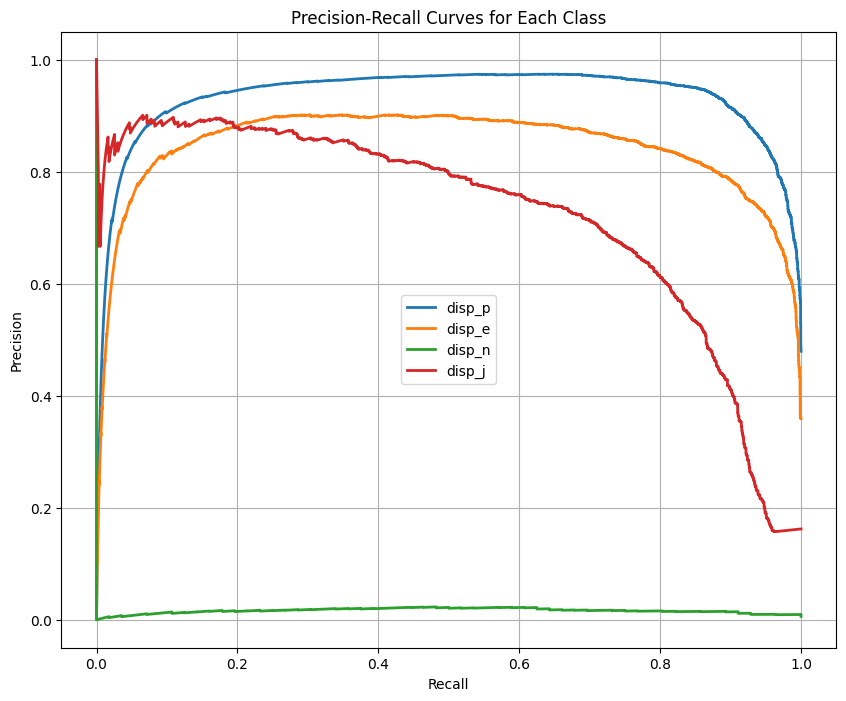

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Create figure
plt.figure(figsize=(10, 8))

# Assuming you have tce_labels with ground truth
# And predictions is your DataFrame with model predictions

# Make sure you have predictions defined - this should be the output from your model
# For example, if you ran predict.predict() and stored the result:
# predictions, _ = predict.predict(model_dir=model_path, data_files=test_files, output_file=None)

# For each label, calculate precision-recall curve
for label in labels:
    # Convert to binary classification: 1 for this class, 0 for others
    y_true_binary = (tce_labels[label].values > 0).astype(int)

    # Get predictions for this class
    # Replace 'predictions' with whatever variable holds your prediction results
    y_scores = combined_predictions[label].values

    # Calculate precision-recall curve
    precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)

    # Plot
    plt.plot(recall, precision, lw=2, label=f'{label}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.title('Precision-Recall Curves for Each Class')
plt.grid(True)
plt.show()

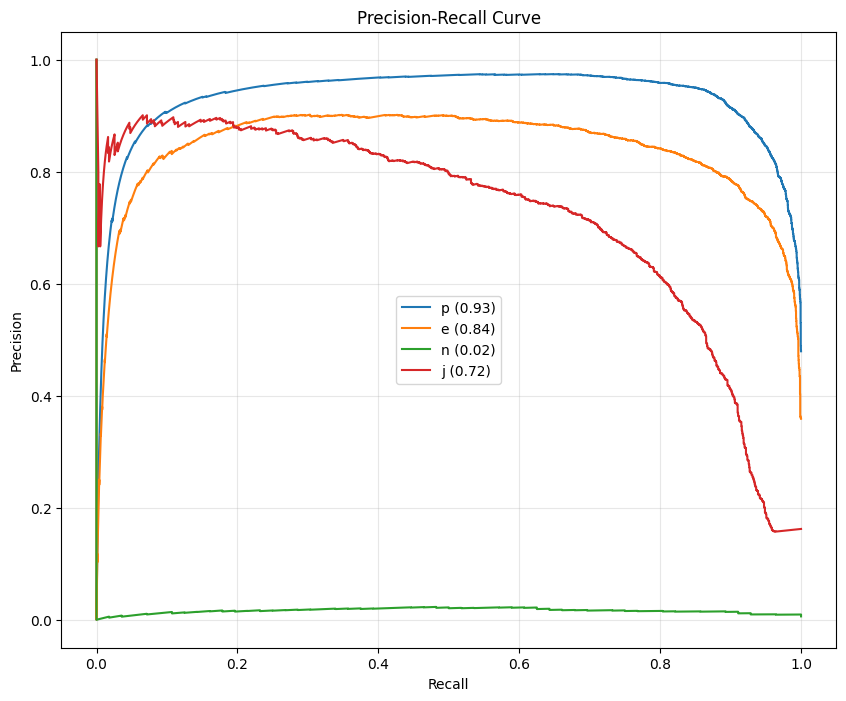

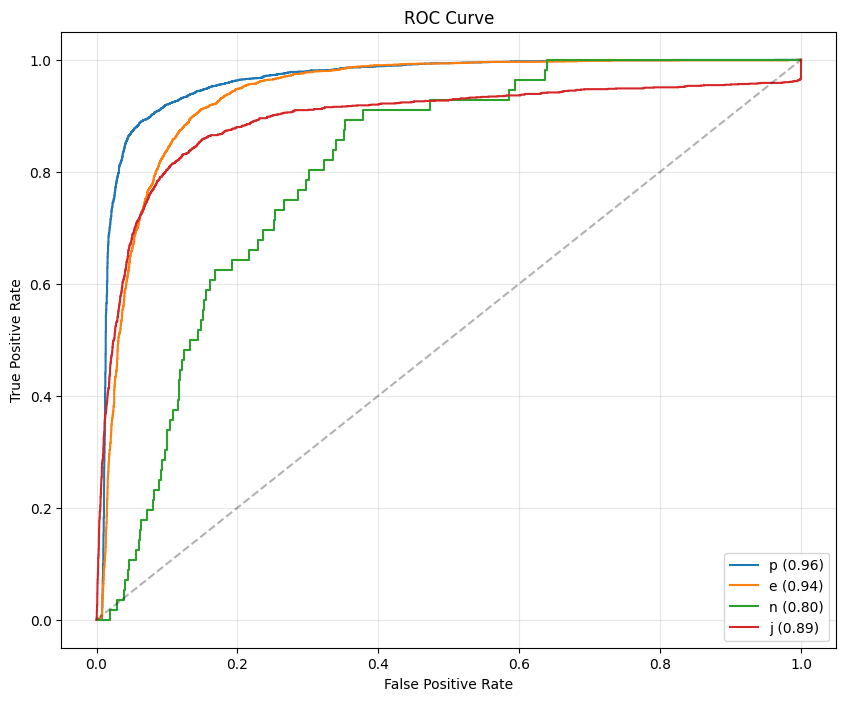

<Figure size 800x600 with 0 Axes>

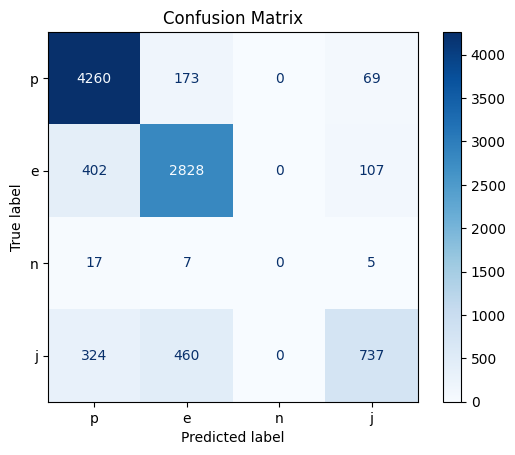

<Figure size 800x600 with 0 Axes>

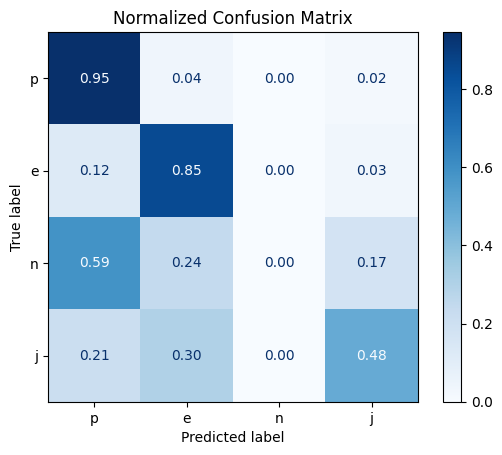

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix, auc
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

# Convert your predictions and labels to numpy arrays
# Assuming tce_labels and predictions are DataFrames containing your data
y_true = tce_labels[labels].values.astype(bool)
y_pred_scores = combined_predictions[labels].values

# Store TIC IDs for reference
astro_ids = tce_labels.index.tolist()
tic_ids = tce_labels['TIC ID'].values if 'TIC ID' in tce_labels.columns else None

# 1. Precision-Recall Curve with AUC
plt.figure(figsize=(10, 8))
for l, label in enumerate(labels):
    precision, recall, thresholds = precision_recall_curve(y_true[:, l], y_pred_scores[:, l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='best')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.show()

# 2. ROC Curve with AUC
plt.figure(figsize=(10, 8))
for l, label in enumerate(labels):
    fpr, tpr, thresholds = roc_curve(y_true[:, l], y_pred_scores[:, l])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label.split('_')[-1]} ({auc_val:.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.title('ROC Curve')
plt.grid(alpha=0.3)
plt.show()

# 3. Confusion Matrix
# First get the predicted class by taking the argmax of the predicted scores
y_pred_class = np.argmax(y_pred_scores, axis=1)
y_true_class = np.argmax(y_true, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_class, y_pred_class)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[label.split('_')[-1] for label in LABELS]
)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 4. Normalized Confusion Matrix (optional but helpful)
plt.figure(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=[label.split('_')[-1] for label in labels]
)
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('Normalized Confusion Matrix')
plt.show()

In [73]:
tce_table.columns

Index(['Astro ID', 'Dec', 'Decision', 'Depth', 'Dur', 'Epoc', 'File', 'Final',
       'Per', 'RA', 'SMass', 'SRad', 'SRadEst', 'TIC ID', 'Tmag', 'as', 'ch',
       'disp_b', 'disp_e', 'disp_j', 'disp_n', 'disp_p', 'disp_t', 'disp_u',
       'dm', 'et', 'md', 'mk'],
      dtype='object')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Define what constitutes a "long period"
long_period = 20  # days - adjust as needed

# Get the period data - adjust the column name as needed
period_data = tce_table['Per'] if 'Per' in tce_table.columns else None

# Create mask for long-period TCEs
long_period_mask = period_data >= long_period

# Extract full dataset and long-period subset
y_true = tce_labels[labels].values.astype(bool)
y_pred_scores = combined_predictions[labels].values

y_true_long = y_true[long_period_mask]
y_pred_scores_long = y_pred_scores[long_period_mask]

# Create the comparison plot
plt.figure(figsize=(12, 8))
labels_to_plot = ['disp_p', 'disp_e']  # Focusing on planets and eclipsing binaries

for l, label in enumerate(labels_to_plot):
    idx = labels.index(label)

    # Compute PR curve for all periods
    precision, recall, _ = precision_recall_curve(y_true[:, idx], y_pred_scores[:, idx])
    auc_val = auc(recall, precision)
    num_events = np.sum(y_true[:, idx])
    plt.plot(recall, precision,
             label=f"{label.split('_')[-1]} (AUC: {auc_val:.2f}, N={num_events})")

    # Compute PR curve for long-period cases
    precision_long, recall_long, _ = precision_recall_curve(
        y_true_long[:, idx], y_pred_scores_long[:, idx])
    auc_val_long = auc(recall_long, precision_long)
    num_events_long = np.sum(y_true_long[:, idx])
    plt.plot(recall_long, precision_long, linestyle='dashed',
             label=f"{label.split('_')[-1]} (AUC: {auc_val_long:.2f}, N={num_events_long}) - per ≥ {long_period}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f'Precision-Recall Curve: All Periods vs. Long Periods (≥ {long_period} days)')
plt.show()

# Print statistics
print(f"Total TCEs: {len(y_true)}")
print(f"Long period TCEs (≥ {long_period} days): {len(y_true_long)} ({len(y_true_long)/len(y_true):.1%} of total)")
for label in labels_to_plot:
    idx = labels.index(label)
    all_pos = np.sum(y_true[:, idx])
    long_pos = np.sum(y_true_long[:, idx])
    print(f"{label}: {all_pos} total positives, {long_pos} long-period positives ({long_pos/all_pos:.1%})")

TypeError: '>=' not supported between instances of 'NoneType' and 'int'